Problem Description:
Consider the task of image classification using a standard visual recognition dataset.
The objective of this part is to study and compare the performance, robustness, and
computational efficiency of convolutional neural network (CNN) architectures trained
from scratch and using transfer learning techniques.
You are required to use the CIFAR-100 dataset, which consists of 100 object classes.
Each input sample is a 32×32 RGB image, and the model output is a categorical label
corresponding to one of the 100 object categories. The dataset contains 50,000 training
images and 10,000 test images.

<div align="center">
----------------------------------------------------------------------------------------------XXXXXXXXXXXXXXXXXXXXXX----------------------------------------------------------------------------------------------
</div>

Loading and inspecting the data to understand the given dataset

In [9]:
%pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
  Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torch-2.12.0.dev20260408%2Bcu128-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torchvision-0.27.0.dev20260407%2Bcu128-cp313-cp313-win_amd64.whl.metadata (5.6 kB)
  Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torchaudio-2.11.0.dev20260407%2Bcu128-cp313-cp313-win_amd64.whl.metadata (7.0 kB)
Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torch-2.12.0.dev20260408%2Bcu128-cp313-cp313-win_amd64.whl (2761.3 MB)
Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torchvision-0.27.0.dev20260407%2Bcu128-cp313-cp313-win_amd64.whl (9.9 MB)
Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torchaudio-2.11.0.dev20260407%2Bcu128-cp313-cp313-win_amd64.whl (1.7 MB)

   ---------------------------------------- 0/3 [torchaudio]
   ------------- -----------

In [10]:
#import necessary libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

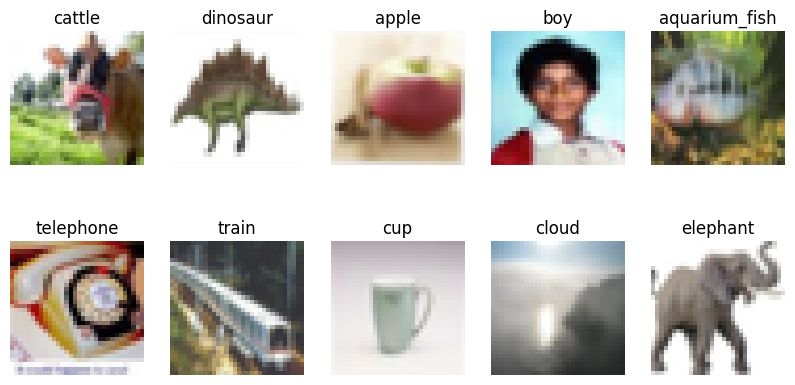

In [11]:
#method to load the dataset pickle file and view/process the images
def load_cifar100(file_path):
    """
    this method uses pickle library to load the train, test, and the metadata file, returns a dictionary
    """
    with open(file_path, 'rb') as f:
        data = pickle.load(f, encoding='bytes')
    return data

train_data = load_cifar100(r'D:\machine_learning\datasets\cifar_100\cifar-100-python\train')
test_data = load_cifar100(r'D:\machine_learning\datasets\cifar_100\cifar-100-python\test')
metadata = load_cifar100(r'D:\machine_learning\datasets\cifar_100\cifar-100-python\meta')

# print(train_data.keys())  #prints - dict_keys([b'filenames', b'batch_label', b'fine_labels', b'coarse_labels', b'data'])

fine_label_names = metadata[b'fine_label_names'] #this reads the metadatafile and gets the class names

plt.figure(figsize=(10,5))

for i in range(10):
    img = train_data[b'data'][i].reshape(3,32,32) #since each image is 3072 bytes long we need to reshape the numpy array so that image can be truly represented, here I have refactored the 3072 bytes into 3 channel images of 32x32 resolution. currently it is (Channels X Height X Width)
    img = np.transpose(img, (1,2,0)) # taking a transpose of the image from (Channels X Height X Width) to (Height X Width X Channels) so that matplotlib can plot it, while pytorch uses CxHxW, matplotlib uses HxWxC

    label = train_data[b'fine_labels'][i] # this gets the class number from the train file
    class_name = fine_label_names[label].decode('utf-8') #this maps the class name with class number from metadata and training file


    plt.subplot(2,5, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off') #remove the axis markings
plt.show();

In [12]:
#check all available classes
label_names = [name.decode('utf-8') for name in fine_label_names]
for i, name in enumerate(label_names):
    print(f"{i}: {name}")
#there are 100 classes in the dataset

0: apple
1: aquarium_fish
2: baby
3: bear
4: beaver
5: bed
6: bee
7: beetle
8: bicycle
9: bottle
10: bowl
11: boy
12: bridge
13: bus
14: butterfly
15: camel
16: can
17: castle
18: caterpillar
19: cattle
20: chair
21: chimpanzee
22: clock
23: cloud
24: cockroach
25: couch
26: crab
27: crocodile
28: cup
29: dinosaur
30: dolphin
31: elephant
32: flatfish
33: forest
34: fox
35: girl
36: hamster
37: house
38: kangaroo
39: keyboard
40: lamp
41: lawn_mower
42: leopard
43: lion
44: lizard
45: lobster
46: man
47: maple_tree
48: motorcycle
49: mountain
50: mouse
51: mushroom
52: oak_tree
53: orange
54: orchid
55: otter
56: palm_tree
57: pear
58: pickup_truck
59: pine_tree
60: plain
61: plate
62: poppy
63: porcupine
64: possum
65: rabbit
66: raccoon
67: ray
68: road
69: rocket
70: rose
71: sea
72: seal
73: shark
74: shrew
75: skunk
76: skyscraper
77: snail
78: snake
79: spider
80: squirrel
81: streetcar
82: sunflower
83: sweet_pepper
84: table
85: tank
86: telephone
87: television
88: tiger
89: t

In [13]:
#check how many images are available per class
label_counts = Counter(train_data[b'fine_labels'])

for label, count in sorted(label_counts.items()):
    print(f"{label_names[label]}: {count}")

#conclusion - dataset is very balanced with 500 images for every class.

apple: 500
aquarium_fish: 500
baby: 500
bear: 500
beaver: 500
bed: 500
bee: 500
beetle: 500
bicycle: 500
bottle: 500
bowl: 500
boy: 500
bridge: 500
bus: 500
butterfly: 500
camel: 500
can: 500
castle: 500
caterpillar: 500
cattle: 500
chair: 500
chimpanzee: 500
clock: 500
cloud: 500
cockroach: 500
couch: 500
crab: 500
crocodile: 500
cup: 500
dinosaur: 500
dolphin: 500
elephant: 500
flatfish: 500
forest: 500
fox: 500
girl: 500
hamster: 500
house: 500
kangaroo: 500
keyboard: 500
lamp: 500
lawn_mower: 500
leopard: 500
lion: 500
lizard: 500
lobster: 500
man: 500
maple_tree: 500
motorcycle: 500
mountain: 500
mouse: 500
mushroom: 500
oak_tree: 500
orange: 500
orchid: 500
otter: 500
palm_tree: 500
pear: 500
pickup_truck: 500
pine_tree: 500
plain: 500
plate: 500
poppy: 500
porcupine: 500
possum: 500
rabbit: 500
raccoon: 500
ray: 500
road: 500
rocket: 500
rose: 500
sea: 500
seal: 500
shark: 500
shrew: 500
skunk: 500
skyscraper: 500
snail: 500
snake: 500
spider: 500
squirrel: 500
streetcar: 500
su

Question A1. Design and train a convolutional neural network from scratch for image classification on the CIFAR-100 dataset. The network should be of moderate size and computationally feasible to train using available resources. Clearly describe the architecture, including the number of convolutional layers, kernel sizes, activation functions, and pooling operations. Train the model and report the training and validation accuracy. Comment on the convergence behavior and overall performance.

In [14]:
# Convert train data in usable format for pytorch
X_train = train_data[b'data'].reshape(-1, 3, 32, 32)
y_train = np.array(train_data[b'fine_labels'])

# Convert test data in usable format for pytorch
X_test = test_data[b'data'].reshape(-1, 3, 32, 32)
y_test = np.array(test_data[b'fine_labels'])

# normalizing the data
X_train = X_train / 255.0
X_test = X_test / 255.0

# convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)


train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [15]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)

        self.conv5 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(128*4*4, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 100)

    def forward(self, x):
        x = self.pool(F.relu(self.conv2(F.relu(self.bn1(self.conv1(x))))))
        x = self.pool(F.relu(self.conv4(F.relu(self.bn2(self.conv3(x))))))
        x = self.pool(F.relu(self.conv6(F.relu(self.bn3(self.conv5(x))))))

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device) #using system's GTX 1050 4GB, RTX 5060 on standby

cuda


In [17]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(20):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 1470.8184
Epoch 2, Loss: 1183.4957
Epoch 3, Loss: 1028.1665
Epoch 4, Loss: 926.3850
Epoch 5, Loss: 852.1565
Epoch 6, Loss: 798.9046
Epoch 7, Loss: 749.0623
Epoch 8, Loss: 706.3295
Epoch 9, Loss: 667.1068
Epoch 10, Loss: 633.1349
Epoch 11, Loss: 606.3001
Epoch 12, Loss: 575.9069
Epoch 13, Loss: 547.2013
Epoch 14, Loss: 526.2819
Epoch 15, Loss: 500.2884
Epoch 16, Loss: 480.4608
Epoch 17, Loss: 462.5018
Epoch 18, Loss: 441.1011
Epoch 19, Loss: 427.6344
Epoch 20, Loss: 407.2527


In [18]:
def evaluate(loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

train_acc = evaluate(train_loader)
test_acc = evaluate(test_loader)

print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")


Train Accuracy: 79.96%
Test Accuracy: 49.08%


Question A2. Using the trained model from Question A1, evaluate robustness to noise by injecting additive Gaussian noise into the test images. Use zero-mean Gaussian noise with variance σ^2 = 0.05, assuming input images are normalized to the range [0, 1]. Test the model on the noisy test set and report the resulting performance. Clearly document and store the noise generation process and parameters (noise schedule), as this will be reused in subsequent experiments.

In [19]:
sigma = (0.05) ** 0.5  # standard deviation

def add_gaussian_noise(images, sigma):
    noise = torch.randn_like(images) * sigma
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0) 
    return noisy_images

X_test_noisy = add_gaussian_noise(X_test, sigma)

test_noisy_dataset = TensorDataset(X_test_noisy, y_test)
test_noisy_loader = DataLoader(test_noisy_dataset, batch_size=128, shuffle=False)

noisy_test_acc = evaluate(test_noisy_loader)

print(f"Noisy Test Accuracy: {noisy_test_acc:.2f}%")

Noisy Test Accuracy: 4.06%


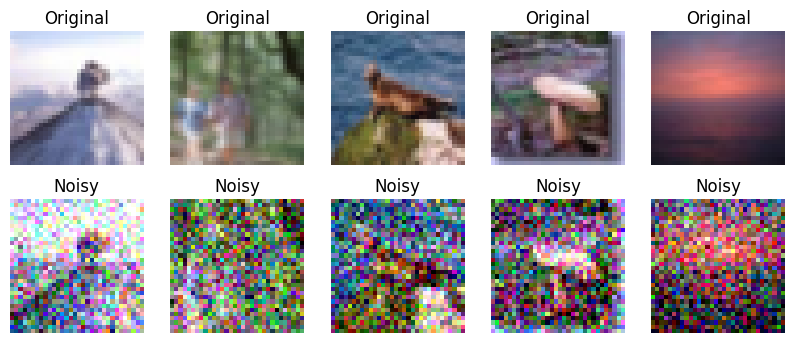

In [20]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].permute(1,2,0))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(X_test_noisy[i].permute(1,2,0))
    plt.title("Noisy")
    plt.axis('off')

plt.show()

Question A3. Design and implement an improved training strategy to mitigate the performance degradation observed under noisy test conditions. Your method should incorporate a limited number of noise-perturbed or semantically similar samples during training, while ensuring that the overall training distribution remains close to the clean dataset. Clearly justify all your modifications and report the performance

In [21]:
noise_prob = 0.3  # 30% noisy samples

for epoch in range(20):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Apply noise to a subset
        if torch.rand(1).item() < noise_prob:
            images = add_gaussian_noise(images, sigma)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 724.9681
Epoch 2, Loss: 649.4914
Epoch 3, Loss: 695.2164
Epoch 4, Loss: 608.0759
Epoch 5, Loss: 632.8099
Epoch 6, Loss: 651.4719
Epoch 7, Loss: 628.0636
Epoch 8, Loss: 591.0536
Epoch 9, Loss: 616.3935
Epoch 10, Loss: 574.3644
Epoch 11, Loss: 583.0457
Epoch 12, Loss: 594.7694
Epoch 13, Loss: 563.3585
Epoch 14, Loss: 595.2595
Epoch 15, Loss: 580.3043
Epoch 16, Loss: 583.6618
Epoch 17, Loss: 522.0229
Epoch 18, Loss: 559.6799
Epoch 19, Loss: 543.5747
Epoch 20, Loss: 551.7708


In [22]:
clean_acc = evaluate(test_loader)
noisy_acc = evaluate(test_noisy_loader)

print(f"Clean Accuracy: {clean_acc:.2f}%")
print(f"Noisy Accuracy: {noisy_acc:.2f}%")

Clean Accuracy: 36.66%
Noisy Accuracy: 26.78%


Question A4. Apply transfer learning by using a pre-trained VGG network as a feature extractor. Freeze the convolutional layers of the VGG model and extract feature representations for the CIFAR-100 images. Train a small multi-layer perceptron (MLP) classifier using these features. Test the model and report its classification performance. Compare the results with those obtained using the CNN trained from scratch.

In [23]:
#I will have to reshape the images for VGG, it needs 244X244 size while the current size is 32X32

def preprocess_for_vgg(images):
    # Resize 32x32 → 224x224
    images = F.interpolate(images, size=(224, 224), mode='bilinear')

    # Normalize using ImageNet stats
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

    images = (images - mean) / std
    return images

In [24]:
vgg = models.vgg16(pretrained=True)

# Freeze convolutional layers
for param in vgg.features.parameters():
    param.requires_grad = False

vgg = vgg.to(device)
vgg.eval()

c:\Users\Sumed\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Sumed\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [25]:
def extract_features(loader):
    features_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            images = preprocess_for_vgg(images)

            features = vgg.features(images)
            features = torch.flatten(features, 1)

            features_list.append(features.cpu())
            labels_list.append(labels)

    return torch.cat(features_list), torch.cat(labels_list)

In [26]:
X_train_feat, y_train_feat = extract_features(train_loader)
X_test_feat, y_test_feat = extract_features(test_loader)

In [27]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 100)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [28]:
input_dim = X_train_feat.shape[1]

mlp = MLP(input_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)

In [29]:
train_dataset_feat = torch.utils.data.TensorDataset(X_train_feat, y_train_feat)
train_loader_feat = torch.utils.data.DataLoader(train_dataset_feat, batch_size=128, shuffle=True)

for epoch in range(15):
    mlp.train()
    total_loss = 0

    for x, y in train_loader_feat:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = mlp(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 834.1844
Epoch 2, Loss: 505.8489
Epoch 3, Loss: 372.3093
Epoch 4, Loss: 287.0790
Epoch 5, Loss: 234.9420
Epoch 6, Loss: 191.1171
Epoch 7, Loss: 170.3595
Epoch 8, Loss: 157.1337
Epoch 9, Loss: 145.0017
Epoch 10, Loss: 144.8770
Epoch 11, Loss: 132.8416
Epoch 12, Loss: 128.4314
Epoch 13, Loss: 128.6220
Epoch 14, Loss: 124.3494
Epoch 15, Loss: 123.9467


In [30]:
def evaluate_mlp(X, y):
    mlp.eval()
    correct = 0

    with torch.no_grad():
        outputs = mlp(X.to(device))
        _, predicted = torch.max(outputs, 1)
        correct = (predicted.cpu() == y).sum().item()

    return 100 * correct / len(y)

train_acc = evaluate_mlp(X_train_feat, y_train_feat)
test_acc = evaluate_mlp(X_test_feat, y_test_feat)

print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

Train Accuracy: 99.65%
Test Accuracy: 62.18%


Question A5. Evaluate the robustness of the transfer learning approach by injecting additive Gaussian noise, with the same parameters used previously, into the test images.
Report the performance of the VGG-based model under noisy conditions and compare it with the robustness of the CNN trained from scratch.

In [31]:
X_test_noisy_feat, y_test_noisy = extract_features(torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test_noisy, y_test),batch_size=128,shuffle=False))

In [32]:
noisy_test_acc_vgg = evaluate_mlp(X_test_noisy_feat, y_test_noisy)

print(f"VGG Noisy Test Accuracy: {noisy_test_acc_vgg:.2f}%")

VGG Noisy Test Accuracy: 2.06%
